In [1]:
# Parameters
DATA_PATH = "data/raw/household_power_consumption.txt"
HANDLE_MISSING = "interpolate"
OUTPUT_DIR = "data/processed"
OUTPUT_FILENAME = "cleaned_data.parquet"
PLOT_TIME_SERIES = True
PLOT_DISTRIBUTIONS = True
PLOT_SEASONAL = True
PLOT_CORRELATION = True
PLOT_ANOMALY_PREVIEW = True


In [2]:
# PARAMETERS (for papermill)

# Đường dẫn file dữ liệu gốc
DATA_PATH = "data/raw/household_power_consumption.txt"

# Phương pháp xử lý missing values: 'interpolate', 'ffill', 'drop'
HANDLE_MISSING = "interpolate"

# Thư mục lưu dữ liệu đã xử lý 
OUTPUT_DIR = "data/processed"

# Tên file output
OUTPUT_FILENAME = "cleaned_data.parquet"

# Một số tham số EDA (bật/tắt nhanh)
PLOT_TIME_SERIES = True
PLOT_DISTRIBUTIONS = True
PLOT_SEASONAL = True
PLOT_CORRELATION = True
PLOT_ANOMALY_PREVIEW = True

In [3]:
# ==================== SETUP ====================
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Xác định project_root linh hoạt
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    # Đang chạy từ thư mục notebooks
    project_root = os.path.abspath("..")
else:
    # Đang chạy từ root project (papermill, VSCode, v.v.)
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Import thư viện tự viết
from energy_forecast_library import DataLoader, Preprocessor, AnomalyDetector, FeatureEngineer, Utils

# Tạo thư mục output nếu chưa có
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)

print(f"✅ Project root: {project_root}")
print(f"✅ Output dir: {OUTPUT_DIR}")
print("✅ Đã import thư viện thành công")

✅ Project root: C:\Users\Admin\DataMining\Household_Power
✅ Output dir: data/processed
✅ Đã import thư viện thành công


In [4]:
# ==================== LOAD DATA ====================
full_path = os.path.join(project_root, DATA_PATH)
df_raw = DataLoader.load_raw_data(full_path)

print("\nThông tin về tập dữ liệu Household Power Consumption:")
print(f"- Kích thước dữ liệu: {df_raw.shape[0]:,} dòng và {df_raw.shape[1]} cột")
print(f"- Thời gian: {df_raw['Date'].min()} → {df_raw['Date'].max()}")

missing_values = df_raw.isnull().sum().sum()
print(f"- Tổng số giá trị thiếu (ước lượng): {missing_values:,} ô (sẽ xác định chính xác sau khi parse)")

df_raw.head()

✅ Đã đọc 2,075,259 dòng từ C:\Users\Admin\DataMining\Household_Power\data/raw/household_power_consumption.txt

Thông tin về tập dữ liệu Household Power Consumption:
- Kích thước dữ liệu: 2,075,259 dòng và 9 cột
- Thời gian: 1/1/2007 → 9/9/2010


- Tổng số giá trị thiếu (ước lượng): 181,853 ô (sẽ xác định chính xác sau khi parse)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
# ==================== PREPROCESSING ====================
# Tạo bản sao để xử lý
df = df_raw.copy()

# 1. Parse datetime
df = Preprocessor.parse_datetime(df)
print(f"✅ Đã parse datetime: {df.index.min()} → {df.index.max()}")

# 2. Chuyển đổi kiểu dữ liệu
df = Preprocessor.convert_columns_to_numeric(df)
print("✅ Đã chuyển đổi kiểu dữ liệu")

# 3. Kiểm tra missing chính xác
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing': missing_count.values,
    'Percent': missing_percent.values
}).sort_values('Percent', ascending=False)

print("\n📊 Missing values:")
print(missing_df[missing_df['Missing'] > 0].to_string(index=False))

# 4. Xử lý missing
df = Preprocessor.handle_missing_values(df, method=HANDLE_MISSING)
print(f"✅ Đã xử lý missing bằng phương pháp: {HANDLE_MISSING}")
print(f"✅ Missing còn lại: {df.isna().sum().sum()}")

✅ Đã parse datetime: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
📊 Tổng số: 2,075,259 dòng
✅ Đã parse datetime: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
✅ Đã chuyển đổi các cột về kiểu số
✅ Đã chuyển đổi kiểu dữ liệu

📊 Missing values:
               Column  Missing  Percent
  Global_active_power    25979 1.251844
Global_reactive_power    25979 1.251844
              Voltage    25979 1.251844
     Global_intensity    25979 1.251844
       Sub_metering_1    25979 1.251844
       Sub_metering_2    25979 1.251844
       Sub_metering_3    25979 1.251844

📊 PHÂN TÍCH MISSING VALUES
   - Tổng số ô: 14,526,813
   - Missing trước xử lý: 181,853 ô
   - Tỷ lệ missing: 1.2518%
   - Theo UCI: ~1.25%
------------------------------------------------------------

📌 Missing theo cột:
   - Global_active_power: 25,979 dòng (1.2518%)
   - Global_reactive_power: 25,979 dòng (1.2518%)
   - Voltage: 25,979 dòng (1.2518%)
   - Global_intensity: 25,979 dòng (1.2518%)
   - Sub_metering_1: 25,979 dòng (1.2518%)



✅ KẾT QUẢ XỬ LÝ:
   - Missing sau xử lý: 179,179 ô
   - Đã xử lý: 2,674 ô
   - Phương pháp: interpolate

✅ Đã xử lý missing bằng phương pháp: interpolate
✅ Missing còn lại: 179179


In [6]:
# ==================== BASIC STATISTICS ====================
print("📊 Thống kê mô tả:")
df.describe()

📊 Thống kê mô tả:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049662e+06,2.049662e+06,2.049662e+06,2.049662e+06,2.049662e+06,2.049662e+06,2.049662e+06
mean,1.091648e+00,1.237253e-01,2.408397e+02,4.627905e+00,1.121824e+00,1.298465e+00,6.458458e+00
std,1.057285e+00,1.127295e-01,3.240065e+00,4.444353e+00,6.152761e+00,5.821653e+00,8.437152e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [7]:
# ==================== ANOMALY PREVIEW ====================
if PLOT_ANOMALY_PREVIEW:
    # Phát hiện sơ bộ anomaly để xem
    df_with_anomalies = AnomalyDetector.mark_anomalies(df, 'Global_active_power', method='both')
    
    n_anomalies = df_with_anomalies['is_anomaly'].sum()
    print(f"🔍 Phát hiện {n_anomalies} điểm bất thường ({(n_anomalies/len(df))*100:.2f}%)")
    
    # Xem một vài điểm anomaly
    df_with_anomalies[df_with_anomalies['is_anomaly']].head(10)

✅ Phát hiện 94925 điểm bất thường (4.5741%)
🔍 Phát hiện 94925 điểm bất thường (4.57%)


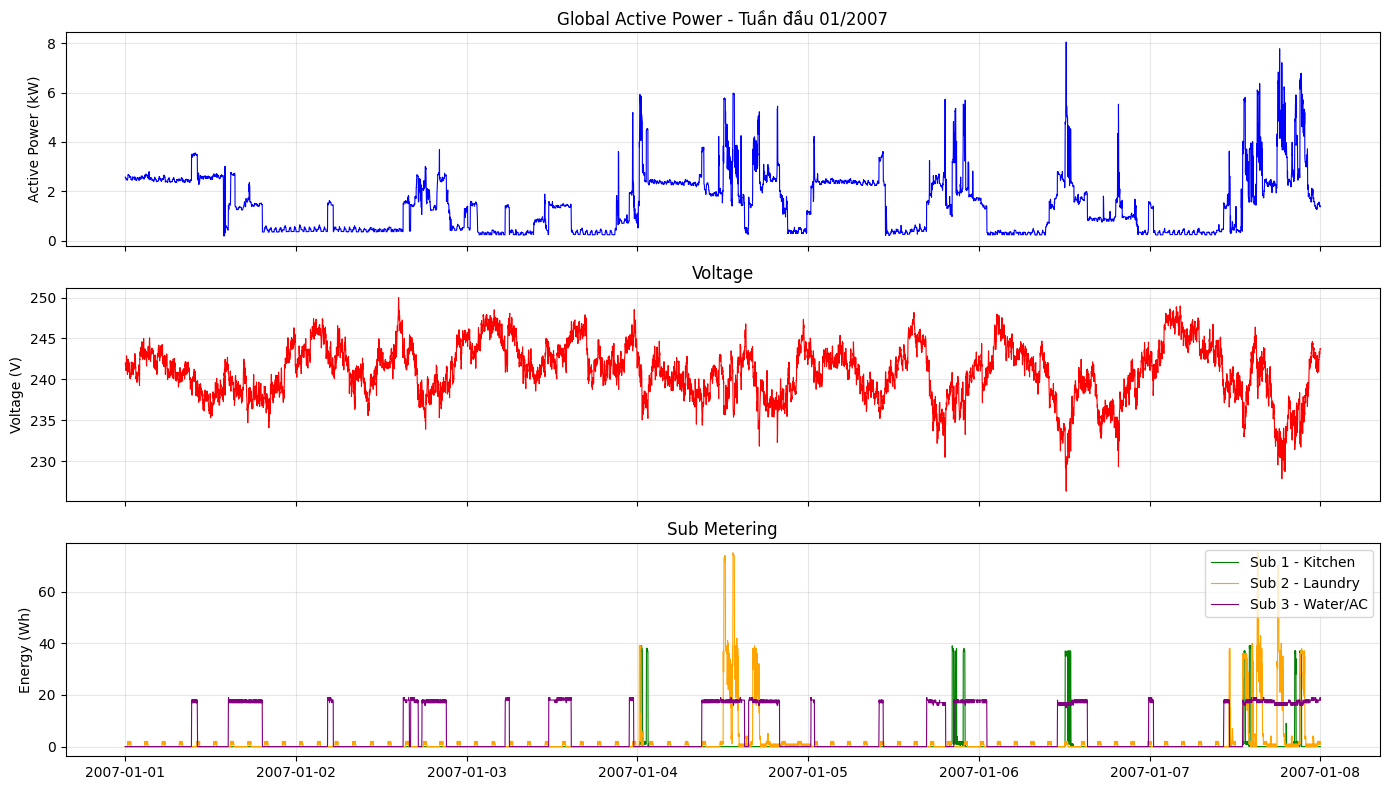

In [8]:
# ==================== TIME SERIES PLOT ====================
if PLOT_TIME_SERIES:
    # Lấy mẫu 1 tuần để dễ nhìn
    sample_data = df['2007-01-01':'2007-01-07']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    # Global Active Power
    axes[0].plot(sample_data.index, sample_data['Global_active_power'], 
                 color='blue', linewidth=0.8)
    axes[0].set_ylabel('Active Power (kW)')
    axes[0].set_title('Global Active Power - Tuần đầu 01/2007')
    axes[0].grid(True, alpha=0.3)
    
    # Voltage
    axes[1].plot(sample_data.index, sample_data['Voltage'], 
                  color='red', linewidth=0.8)
    axes[1].set_ylabel('Voltage (V)')
    axes[1].set_title('Voltage')
    axes[1].grid(True, alpha=0.3)
    
    # Sub metering
    axes[2].plot(sample_data.index, sample_data['Sub_metering_1'], 
                  color='green', linewidth=0.8, label='Sub 1 - Kitchen')
    axes[2].plot(sample_data.index, sample_data['Sub_metering_2'], 
                  color='orange', linewidth=0.8, label='Sub 2 - Laundry')
    axes[2].plot(sample_data.index, sample_data['Sub_metering_3'], 
                  color='purple', linewidth=0.8, label='Sub 3 - Water/AC')
    axes[2].set_ylabel('Energy (Wh)')
    axes[2].set_title('Sub Metering')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/time_series.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

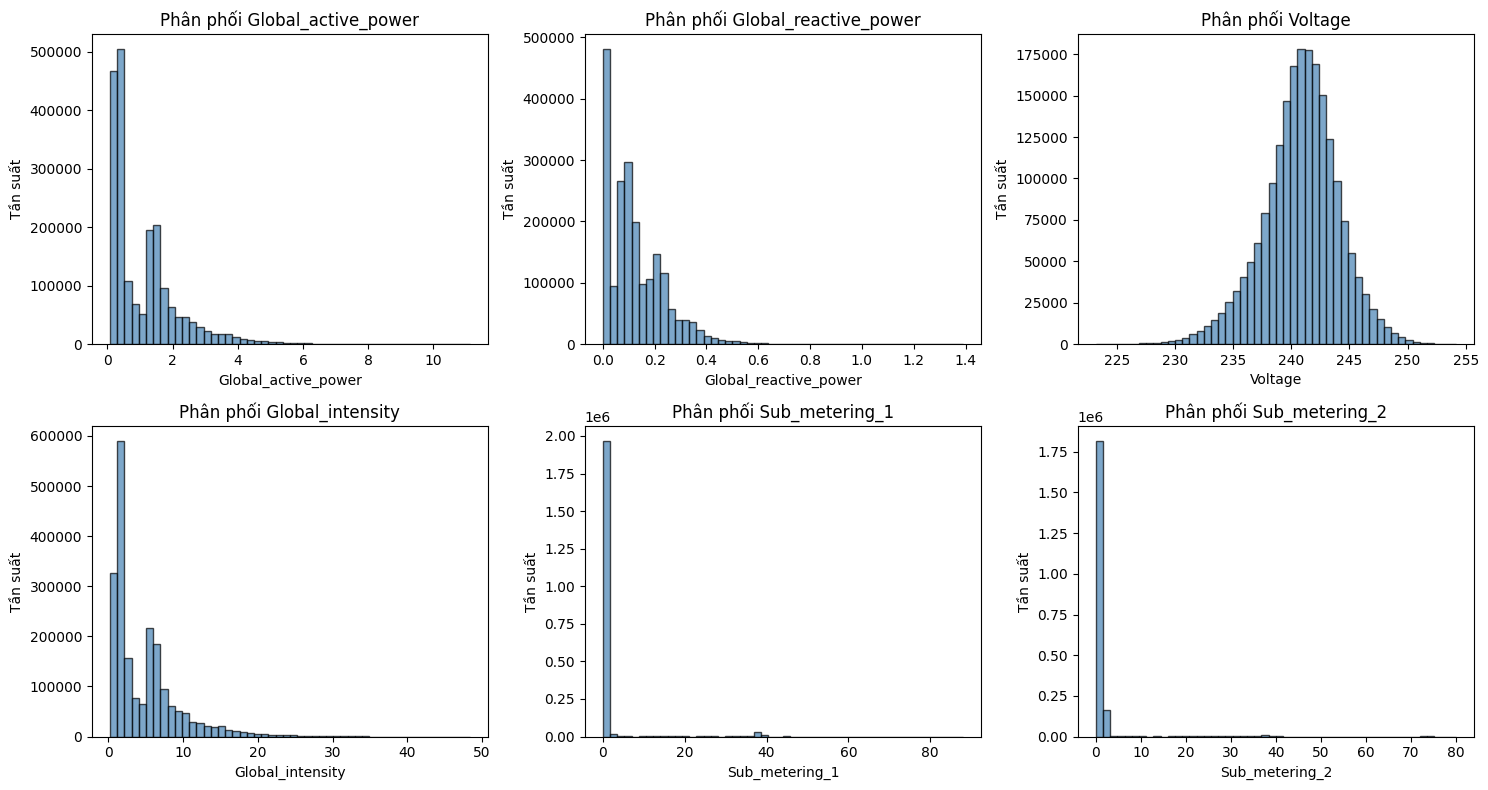

In [9]:
# ==================== DISTRIBUTIONS ====================
if PLOT_DISTRIBUTIONS:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    columns = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
               'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
    
    for idx, col in enumerate(columns):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Phân phối {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Tần suất')
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/distributions.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

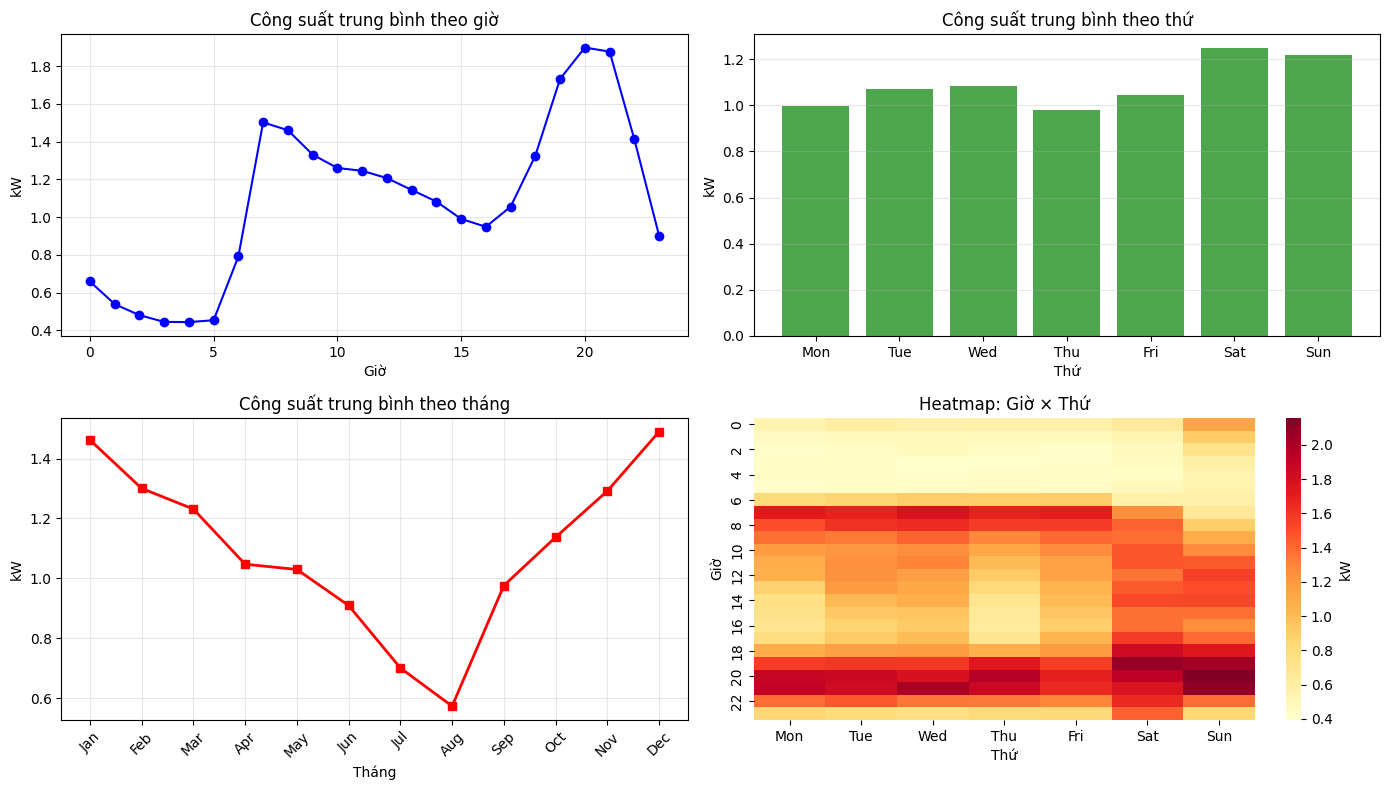

📈 Phát hiện:
- Peak sáng: 1.35 kW (8-11h)
- Peak tối: 1.71 kW (18-22h)
- Cuối tuần: 1.23 kW vs Ngày thường: 1.04 kW
- Mùa đông: 1.42 kW (Dec-Feb)
- Mùa hè: 0.73 kW (Jun-Aug)


In [10]:
# ==================== SEASONAL PATTERNS ====================
if PLOT_SEASONAL:
    # Tạo features tạm thời để phân tích
    df_analysis = df.copy()
    df_analysis['hour'] = df_analysis.index.hour
    df_analysis['dayofweek'] = df_analysis.index.dayofweek
    df_analysis['month'] = df_analysis.index.month
    
    # Tính trung bình
    hourly_avg = df_analysis.groupby('hour')['Global_active_power'].mean()
    dow_avg = df_analysis.groupby('dayofweek')['Global_active_power'].mean()
    monthly_avg = df_analysis.groupby('month')['Global_active_power'].mean()
    
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Theo giờ
    axes[0,0].plot(hourly_avg.index, hourly_avg.values, marker='o', 
                    linestyle='-', color='blue')
    axes[0,0].set_title('Công suất trung bình theo giờ')
    axes[0,0].set_xlabel('Giờ')
    axes[0,0].set_ylabel('kW')
    axes[0,0].grid(True, alpha=0.3)
    
    # Theo thứ
    axes[0,1].bar(dow_labels, dow_avg.values, color='green', alpha=0.7)
    axes[0,1].set_title('Công suất trung bình theo thứ')
    axes[0,1].set_xlabel('Thứ')
    axes[0,1].set_ylabel('kW')
    axes[0,1].grid(True, alpha=0.3, axis='y')
    
    # Theo tháng
    axes[1,0].plot(month_labels, monthly_avg.values, marker='s', 
                    linestyle='-', color='red', linewidth=2)
    axes[1,0].set_title('Công suất trung bình theo tháng')
    axes[1,0].set_xlabel('Tháng')
    axes[1,0].set_ylabel('kW')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Heatmap giờ × thứ
    pivot = df_analysis.pivot_table(
        values='Global_active_power', 
        index='hour', 
        columns='dayofweek',
        aggfunc='mean'
    )
    sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd', 
                cbar_kws={'label': 'kW'})
    axes[1,1].set_title('Heatmap: Giờ × Thứ')
    axes[1,1].set_xlabel('Thứ')
    axes[1,1].set_ylabel('Giờ')
    axes[1,1].set_xticklabels(dow_labels)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/seasonal_patterns.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()
    
    print("📈 Phát hiện:")
    print(f"- Peak sáng: {hourly_avg[8:11].mean():.2f} kW (8-11h)")
    print(f"- Peak tối: {hourly_avg[18:22].mean():.2f} kW (18-22h)")
    print(f"- Cuối tuần: {dow_avg[5:7].mean():.2f} kW vs Ngày thường: {dow_avg[0:5].mean():.2f} kW")
    print(f"- Mùa đông: {monthly_avg[[12,1,2]].mean():.2f} kW (Dec-Feb)")
    print(f"- Mùa hè: {monthly_avg[5:8].mean():.2f} kW (Jun-Aug)")

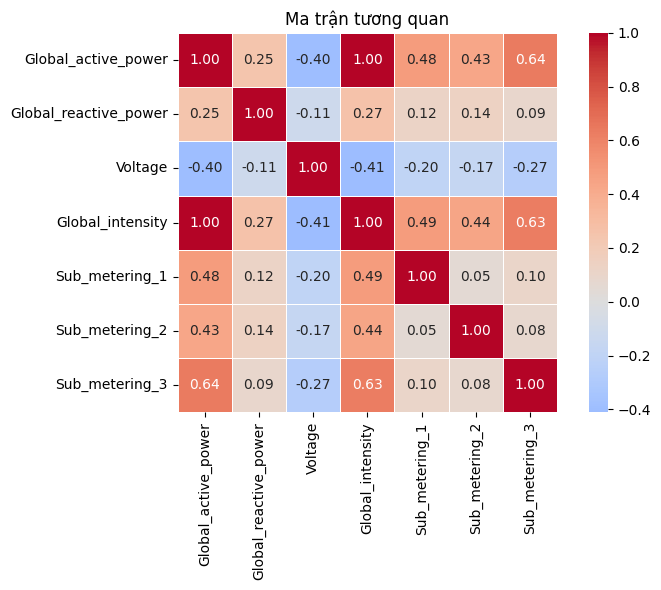

📊 Tương quan mạnh nhất:
- Active Power vs Intensity: 1.00
- Active Power vs Sub 3: 0.64


In [11]:
# ==================== CORRELATION ====================
if PLOT_CORRELATION:
    corr_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    
    corr_matrix = df[corr_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=0.5)
    plt.title('Ma trận tương quan')
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/correlation.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()
    
    print("📊 Tương quan mạnh nhất:")
    print(f"- Active Power vs Intensity: {corr_matrix.loc['Global_active_power', 'Global_intensity']:.2f}")
    print(f"- Active Power vs Sub 3: {corr_matrix.loc['Global_active_power', 'Sub_metering_3']:.2f}")

In [12]:
# ==================== SAVE CLEANED DATA ====================
output_path = os.path.join(project_root, OUTPUT_DIR, OUTPUT_FILENAME)
Utils.save_dataframe(df, output_path)

# Lưu thêm báo cáo missing
missing_path = os.path.join(project_root, OUTPUT_DIR, 'missing_report.csv')
missing_df.to_csv(missing_path, index=False)

print("\n✅ Dữ liệu đã được lưu thành công:")
print(f"- Thư mục: {OUTPUT_DIR}")
print(f"- File: {OUTPUT_FILENAME}")
print(f"- Kích thước: {df.shape[0]:,} dòng, {df.shape[1]} cột")
print(f"- Thời gian: {df.index.min()} → {df.index.max()}")
print("\n✅ Sẵn sàng cho bước tiếp theo: 02_anomaly_detection.ipynb")

✅ Đã lưu 2,075,259 dòng vào C:\Users\Admin\DataMining\Household_Power\data\processed\cleaned_data.parquet

✅ Dữ liệu đã được lưu thành công:
- Thư mục: data/processed
- File: cleaned_data.parquet
- Kích thước: 2,075,259 dòng, 7 cột
- Thời gian: 2006-12-16 17:24:00 → 2010-11-26 21:02:00

✅ Sẵn sàng cho bước tiếp theo: 02_anomaly_detection.ipynb
